In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../dataset/6month_combined_real_synthetic_dataset.csv")
df.head()

,семейное положение,сумма_выдачи(usd),остаток_суммы(usd),процентная ставка,срок кредита (месяц),цикл,цель кредита,возраст,пол,область \город,регион \город,количество членов семьи,образование,должность,shaped_bread(som),cottonseed oil(som),beef(som),is_bad_client
0,married,667,363,72.0,12.0,1.0,"ҳунармандчилик, касаначиликни ривожлантириш",29.0,м,андижон вилояти,избоскан тумани,5.0,среднее,савдогар,2650,17100,76000,1
1,single,1197,185,62.0,18.0,1.0,хизмат курсатиш,42.0,м,фаргона вилояти,кукон шахри,3.0,среднее,курувчи уста,2650,18250,77000,0
2,married,684,337,72.0,12.0,1.0,оилавий ва шахсий эҳтиёжлар (оилавий тадбирлар...,22.0,м,фаргона вилояти,учкуприк тумани,4.0,среднее,тикувчи,2650,19750,77000,0
3,married,322,187,72.0,12.0,1.0,хизмат курсатиш,45.0,м,фаргона вилояти,бешарик тумани,3.0,среднее,уста,2650,19750,77000,0
4,married,402,235,72.0,12.0,1.0,савдо,27.0,м,наманган вилояти,чуст тумани,3.0,среднее,савдогар,2700,17100,76000,0


In [3]:
df['is_bad_client'].value_counts()

0    6000
1    4000
Name: is_bad_client, dtype: int64

In [4]:
feature_cols = [
    'семейное положение', 'сумма_выдачи(usd)', 'процентная ставка',
    'срок кредита (месяц)', 'цикл', 'цель кредита', 'возраст', 'пол',
    'область \город', 'регион \город', 'количество членов семьи', 'образование',
    'должность', 'shaped_bread(som)', 'cottonseed oil(som)', 'beef(som)'
]

In [5]:
target_col = 'is_bad_client'

In [6]:
categorical_cols = [
    'семейное положение', 'цель кредита', 'пол', 'область \город',
    'регион \город', 'образование', 'должность'
]


In [9]:
obj_df = df[feature_cols].select_dtypes(include=['object']).copy()

In [10]:
def find_unique(col, file):
    # print(col,":",obj_df[col].unique())
    unique_values = obj_df[col].unique()
    file.write(f"{col}: {unique_values}\n")

In [11]:
output_filename = 'unique_values.txt'

In [12]:
with open(output_filename, 'w', encoding='utf-8') as f:
    f.write("Unique values for object columns:\n\n")
    
    for col in obj_df.columns:
        find_unique(col, f)

In [7]:
df_encoded = df.copy()
label_encoders = {}

In [8]:
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

In [13]:
X = df_encoded[feature_cols]
y = df_encoded[target_col]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight="balanced"  # Helps with class imbalance
)

In [16]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [17]:
import pickle
# Assume 'model' is your trained Random Forest model
with open('6month_random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

In [18]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [48]:
y_pred = rf_model.predict(X_test)

In [49]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1715   85]
 [ 208  992]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1800
           1       0.92      0.83      0.87      1200

    accuracy                           0.90      3000
   macro avg       0.91      0.89      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [50]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [51]:
thresholds = [7, 9, 11, 13, 15, 17]
thresholds = [t / 100 for t in thresholds]

In [52]:

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

# Define a range of thresholds to test
# thresholds = np.arange(0.1, 1.0, 0.05)

# Create an empty list to store the results
results = []

for threshold in thresholds:
    # Convert probabilities to class predictions based on the current threshold
    y_pred_threshold = (y_probs >= threshold).astype(int)

    # Calculate metrics for the positive class (Class 1)
    precision = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)

    results.append({
        'Threshold': round(threshold, 2),
        'Precision': round(precision, 2),
        'Recall': round(recall, 2),
        'F1-Score': round(f1, 2),
        'Accuracy': round(accuracy, 2)
    })

# Print the results in a formatted table
results_df = pd.DataFrame(results)
print("Model Performance Across Thresholds:")
print(results_df)

Model Performance Across Thresholds:
   Threshold  Precision  Recall  F1-Score  Accuracy
0       0.07       0.53    0.98      0.68      0.64
1       0.09       0.55    0.97      0.70      0.67
2       0.11       0.57    0.97      0.72      0.70
3       0.13       0.60    0.96      0.74      0.73
4       0.15       0.62    0.95      0.75      0.75
5       0.17       0.65    0.94      0.77      0.77


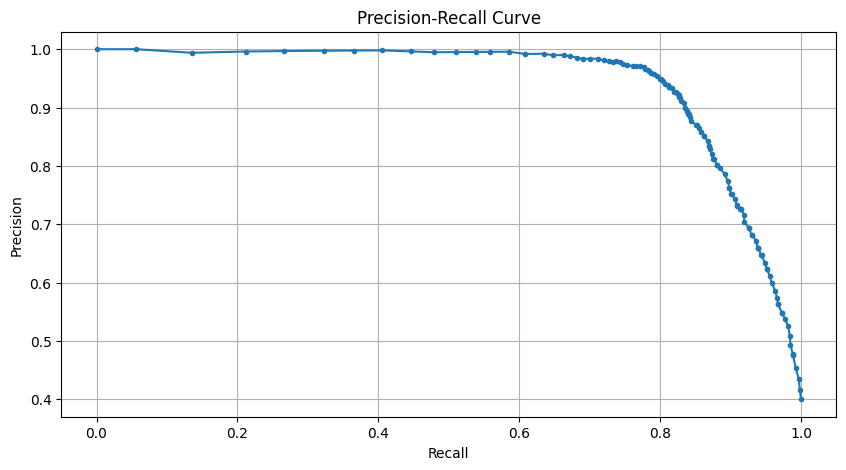

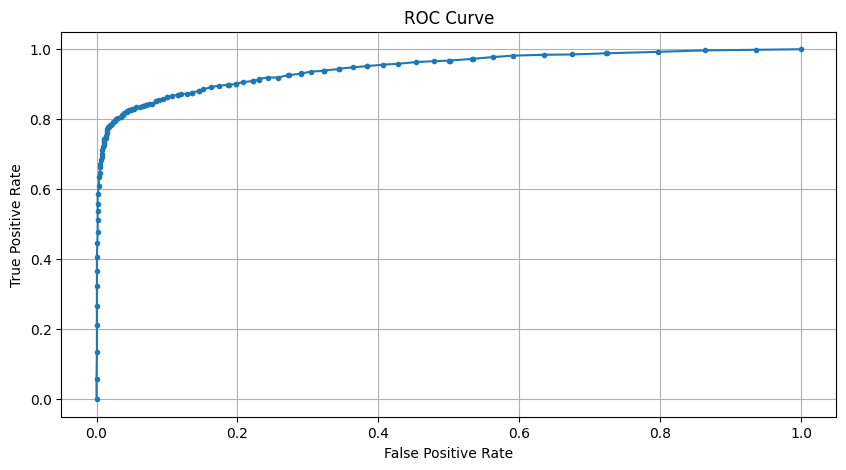

Best Threshold by F1: 0.17, F1-score: 0.7672

Classification Report at Best Threshold:
              precision    recall  f1-score   support

           0       0.95      0.66      0.77      1800
           1       0.65      0.94      0.77      1200

    accuracy                           0.77      3000
   macro avg       0.80      0.80      0.77      3000
weighted avg       0.83      0.77      0.77      3000


Confusion Matrix at Best Threshold:
[[1181  619]
 [  68 1132]]


In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    f1_score,
    classification_report,
    confusion_matrix
)


# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

# Find Best Threshold by F1-score
f1_scores = []
thresholds = [7, 9, 11, 13, 15, 17]
thresholds = [t / 100 for t in thresholds]
# thresholds = np.linspace(0.07, 0.18, 0.2)

# thresholds = np.arange(0.1, 0.91, 0.1)

for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold by F1: {best_thresh:.2f}, F1-score: {max(f1_scores):.4f}")

# Evaluate on Best Threshold
y_pred_best = (y_probs >= best_thresh).astype(int)

print("\nClassification Report at Best Threshold:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix at Best Threshold:")
print(confusion_matrix(y_test, y_pred_best))


In [ ]:
# import networkx as nx
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# # (y_test: 0=good, 1=bad)
# # (y_pred: 0=approved, 1=not approved)

# thresholds = np.arange(0.1, 0.91, 0.1)

# auc_score = roc_auc_score(y_test, y_probs)

# for threshold in thresholds:
#     y_pred = (y_probs >= threshold).astype(int)

#     TN = np.sum((y_pred == 0) & (y_test == 0))
#     FN = np.sum((y_pred == 0) & (y_test == 1))
#     TP = np.sum((y_pred == 1) & (y_test == 1))
#     FP = np.sum((y_pred == 1) & (y_test == 0))

#     approved = TN + FN
#     not_approved = TP + FP

#     acc = accuracy_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
#     npl = round((FN / approved) * 100, 2) if approved > 0 else 0

#     # Создаём граф
#     G = nx.DiGraph()

#     # Узлы
#     G.add_node("Прогноз модели", pos=(2, 5))

#     # Ветви прогноза
#     G.add_node("Плохо\n(Positive)", pos=(0, 4))
#     G.add_node("Хорошо\n(Negative)", pos=(4, 4))

#     # Ветви факта
#     G.add_node(f"TP ✅\nПлохой верно\n{TP}", pos=(-1, 3))
#     G.add_node(f"FP ❌\nХороший ошибочно\n{FP}", pos=(1, 3))
#     G.add_node(f"FN ❌\nПлохой пропущен\n{FN}", pos=(3, 3))
#     G.add_node(f"TN ✅\nХороший верно\n{TN}", pos=(5, 3))

#     # Связи
#     edges = [
#         ("Прогноз модели", "Плохо\n(Positive)"),
#         ("Прогноз модели", "Хорошо\n(Negative)"),

#         ("Плохо\n(Positive)", f"TP ✅\nПлохой верно\n{TP}"),
#         ("Плохо\n(Positive)", f"FP ❌\nХороший ошибочно\n{FP}"),

#         ("Хорошо\n(Negative)", f"FN ❌\nПлохой пропущен\n{FN}"),
#         ("Хорошо\n(Negative)", f"TN ✅\nХороший верно\n{TN}"),
#     ]
#     G.add_edges_from(edges)

#     # Позиции
#     pos = nx.get_node_attributes(G, 'pos')

#     # Цвета
#     node_colors = []
#     for node in G.nodes():
#         if "✅" in node:
#             node_colors.append("#a8e6a3")  # Зелёный
#         elif "❌" in node:
#             node_colors.append("#f4a6a6")  # Красный
#         else:
#             node_colors.append("#fff2a8")  # Жёлтый для заголовков

#     # Рисуем
#     plt.figure(figsize=(10, 6))
#     nx.draw(
#         G, pos,
#         with_labels=True,
#         node_size=4000,
#         node_color=node_colors,
#         font_size=10,
#         edge_color='gray'
#     )

#     metrics_text = f"AUC: {auc_score:.2f}\nF1: {f1:.2f}\nAcc: {acc:.2f}\nNPL: {npl} %"
#     plt.gcf().text(0.75, 0.8, metrics_text, fontsize=12,
#                    bbox=dict(facecolor='lightgrey', alpha=0.3))

#     plt.title(f"Дерево решений при threshold = {threshold:.2f}", fontsize=14)
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()


/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_15070/1062356057.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results mig

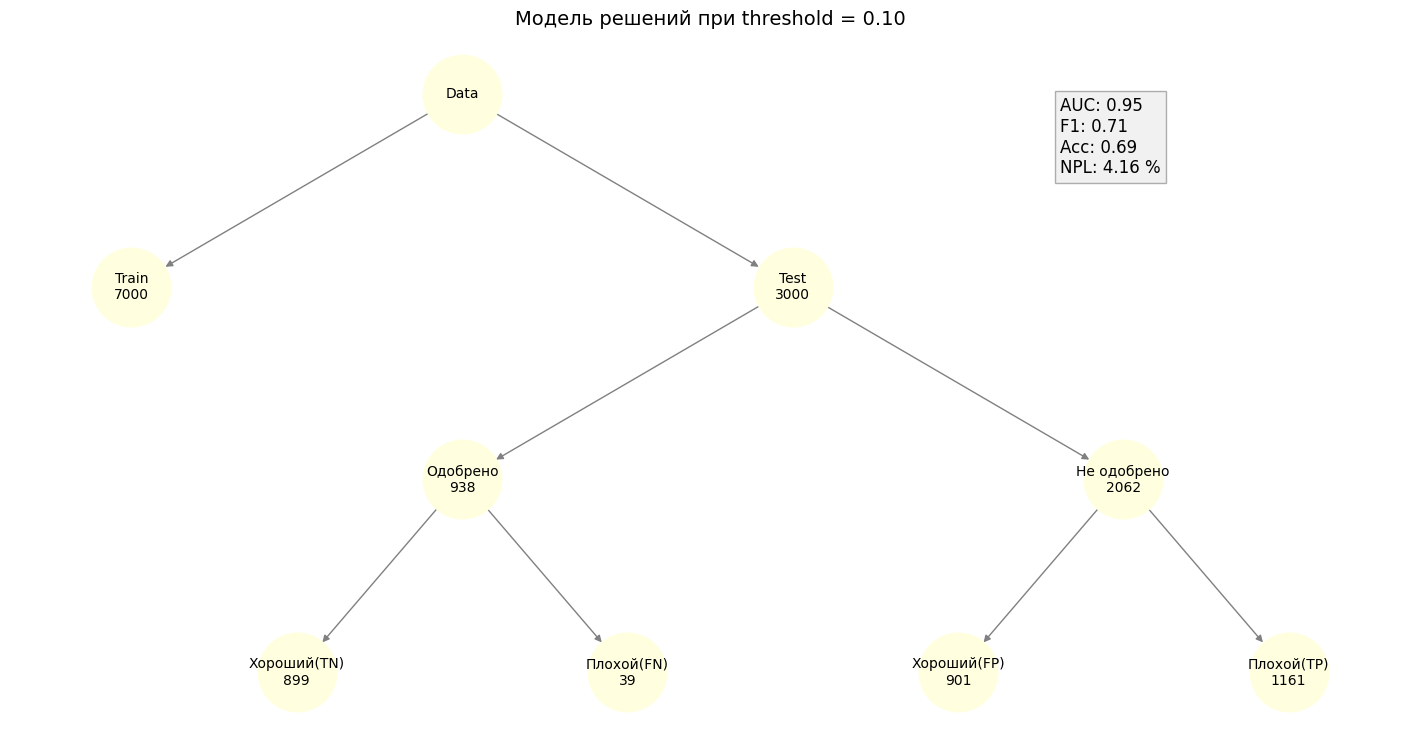

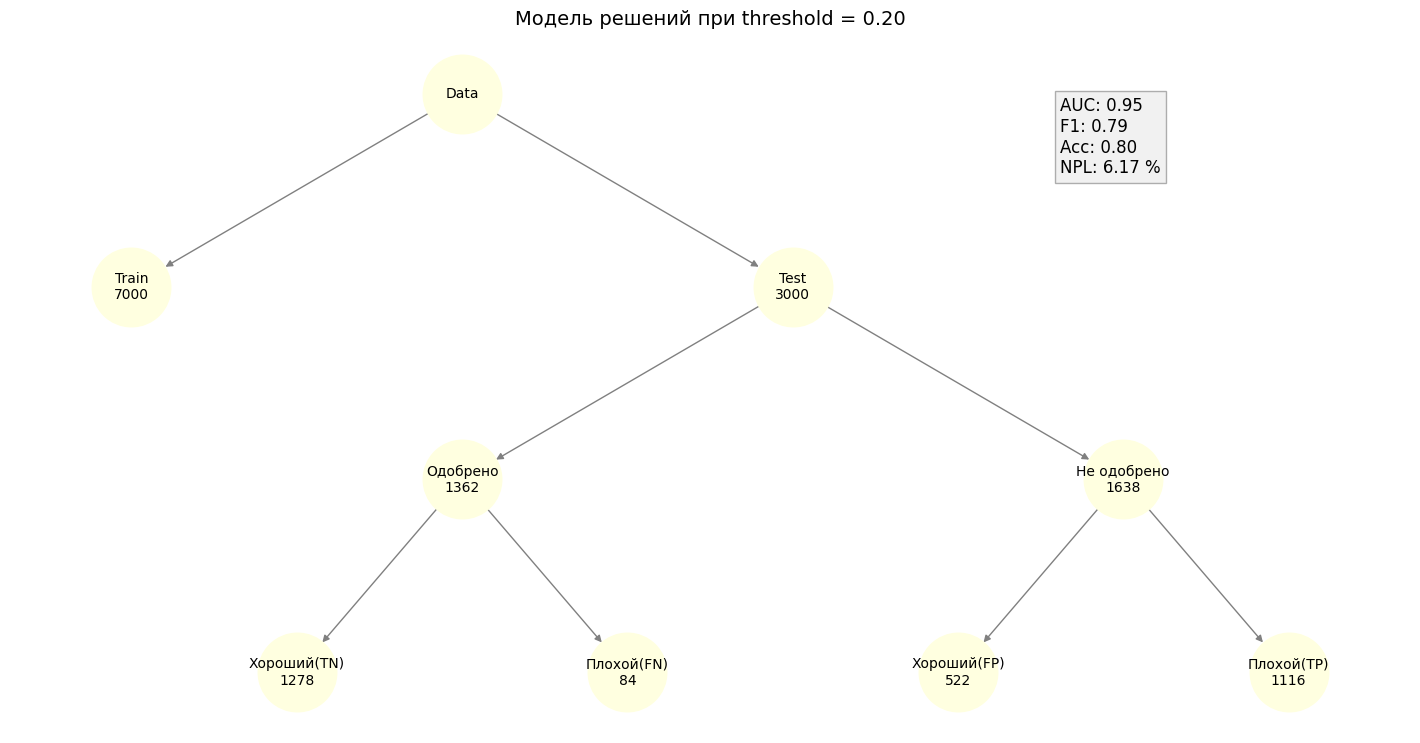

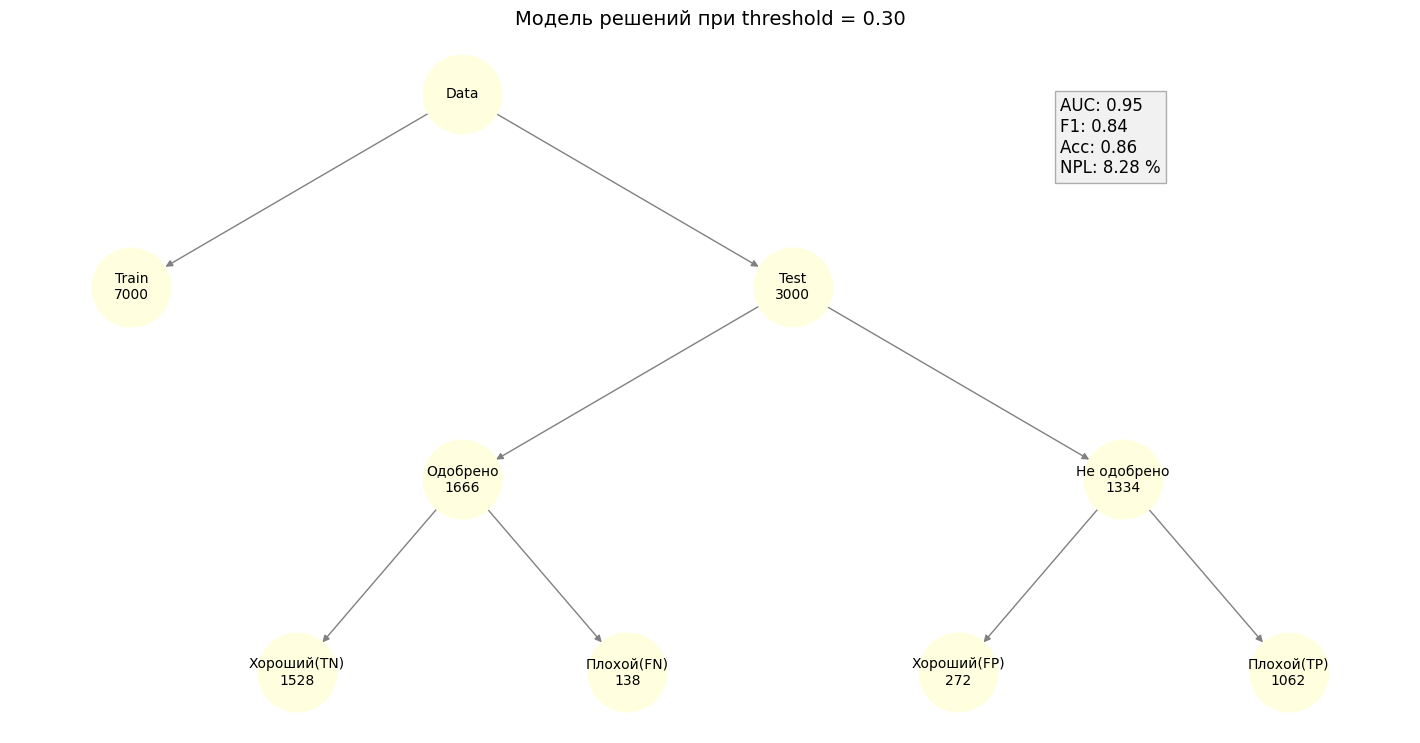

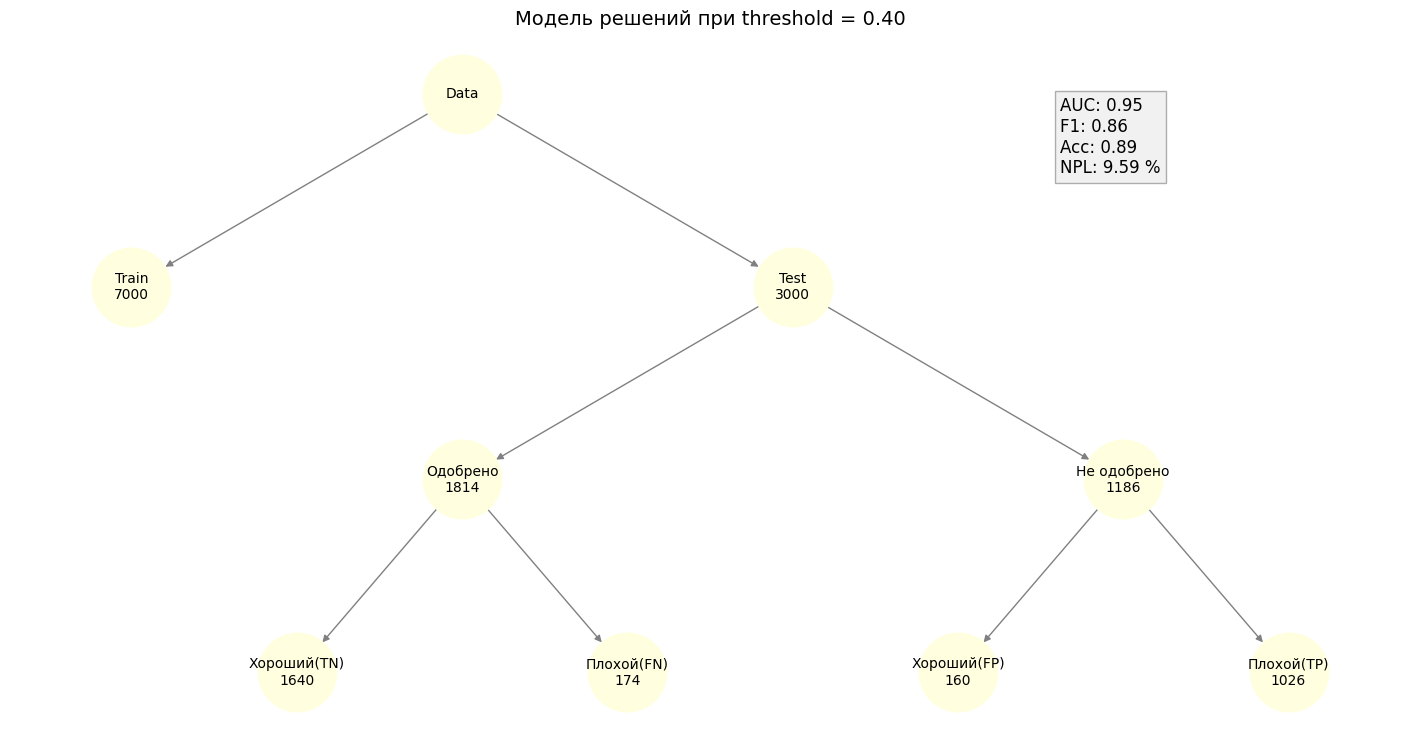

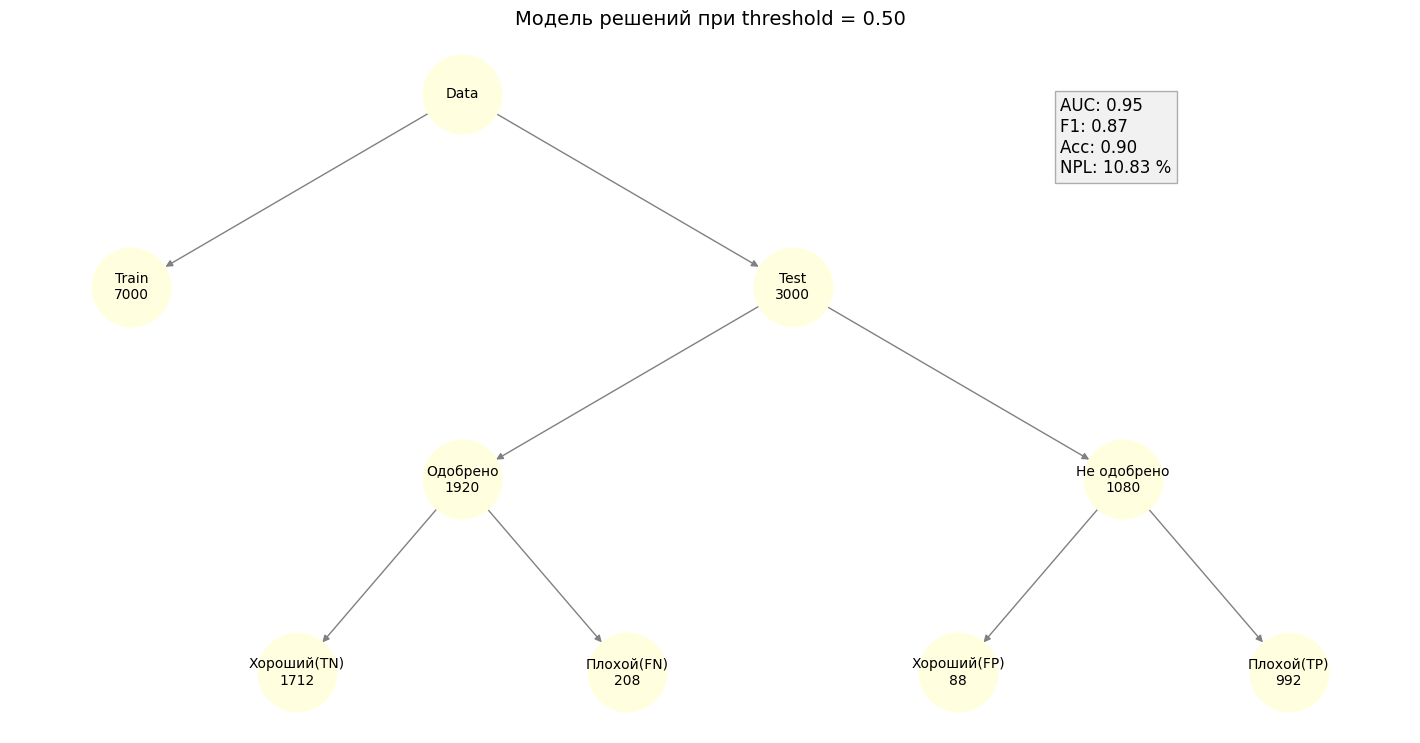

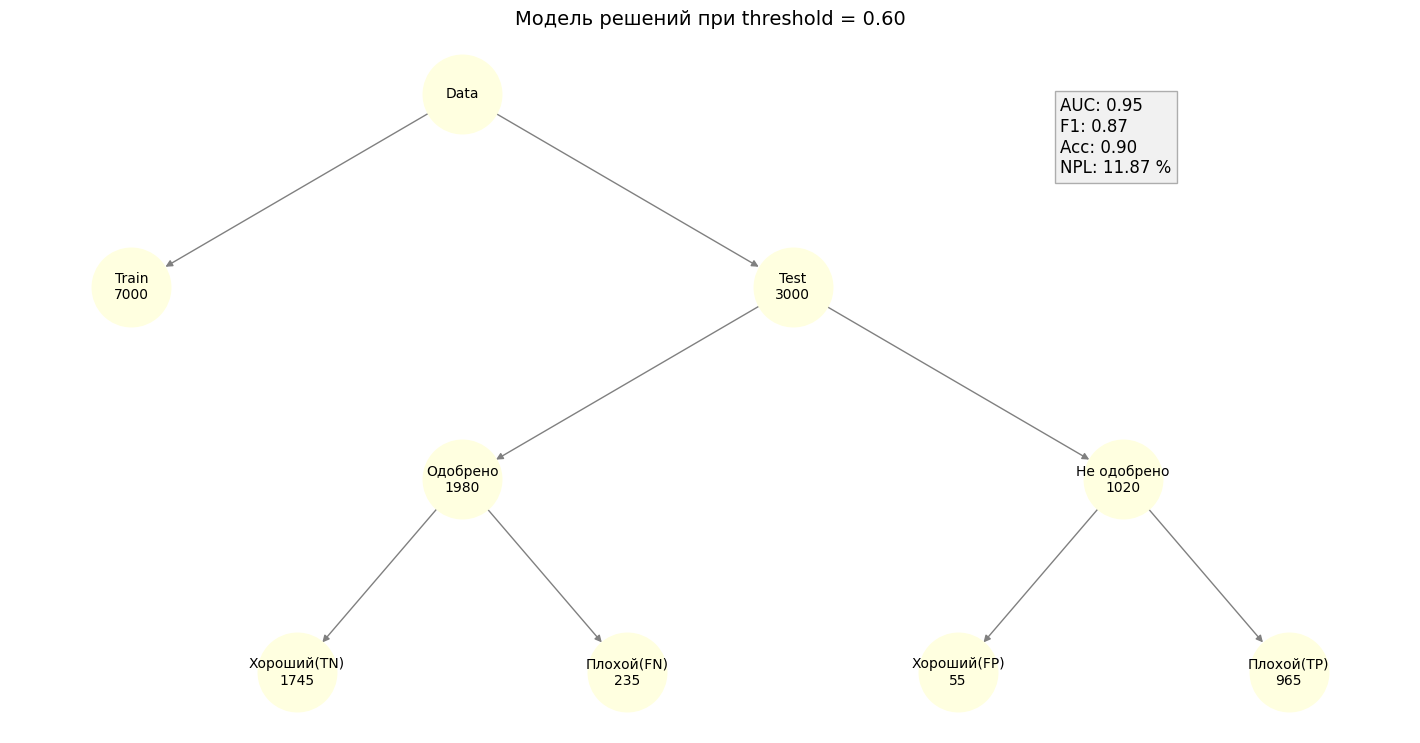

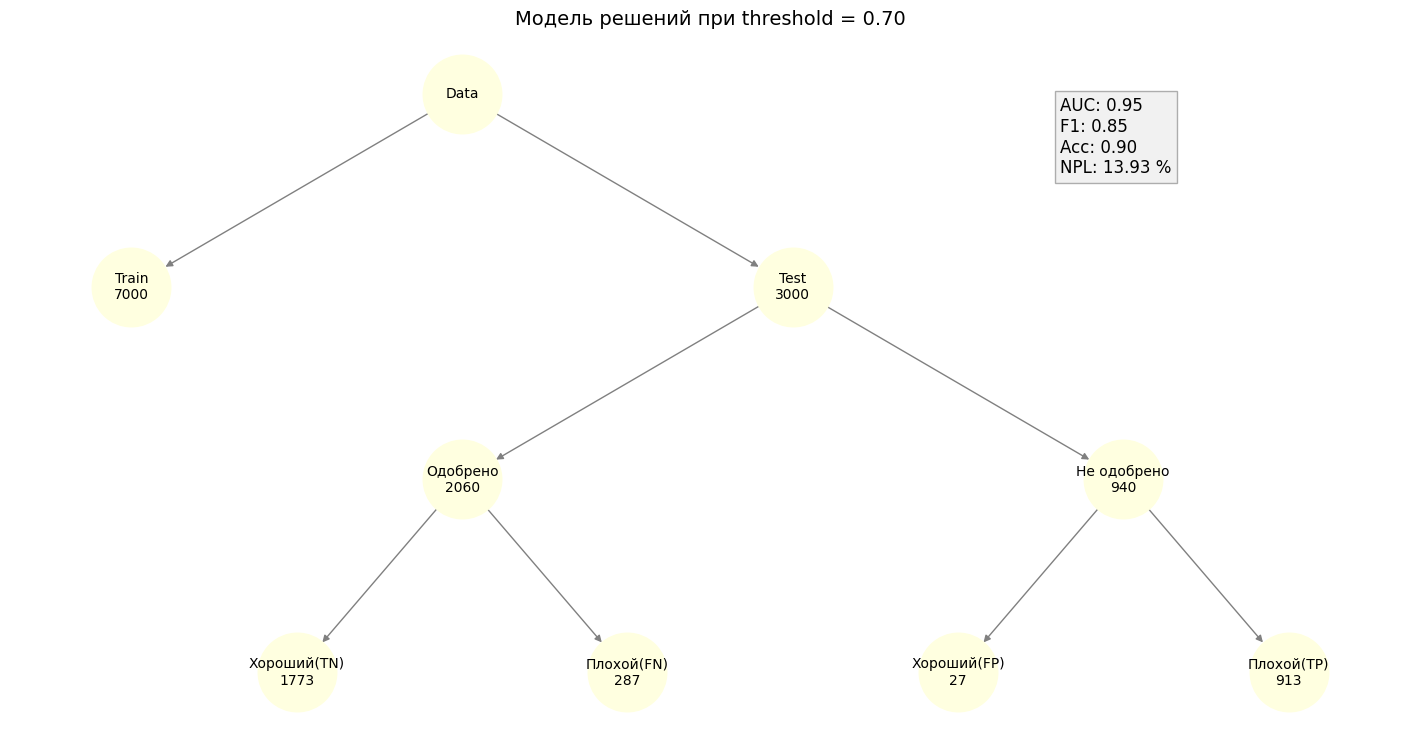

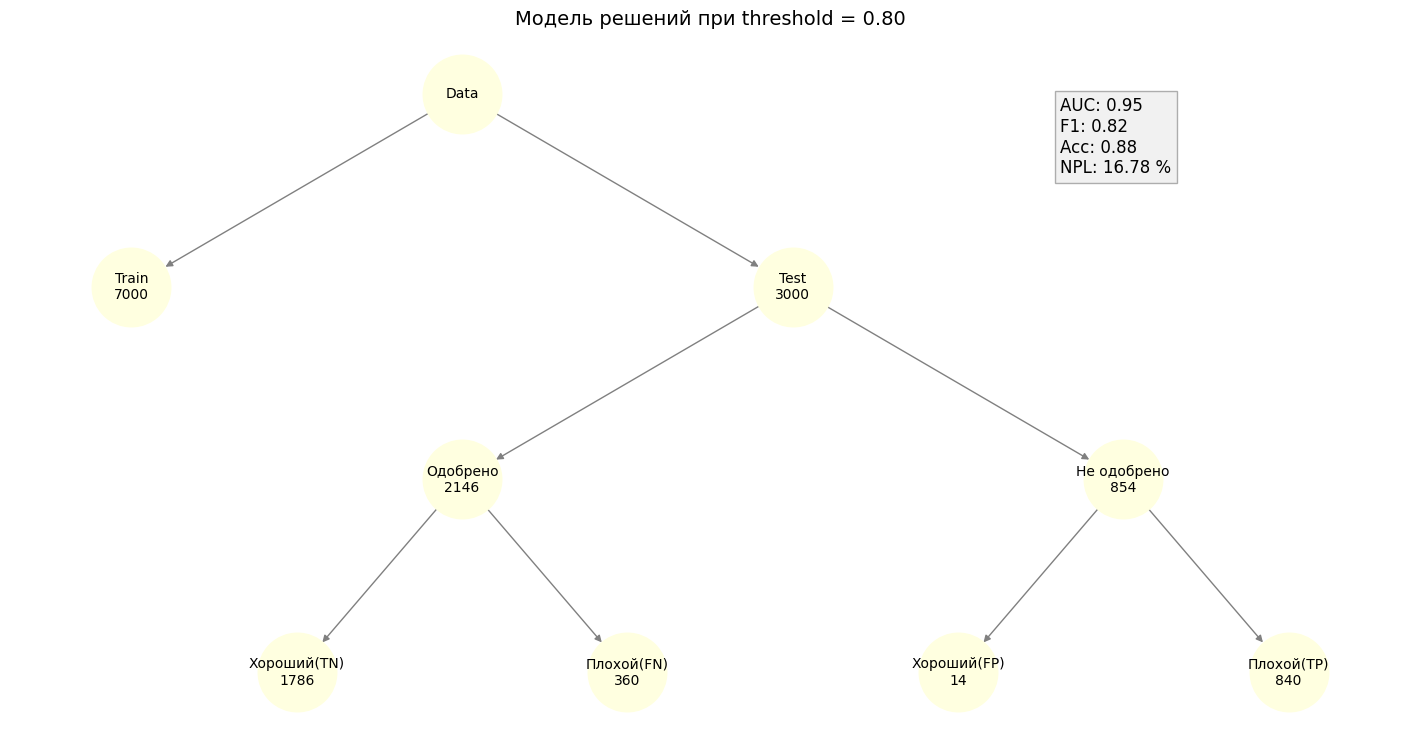

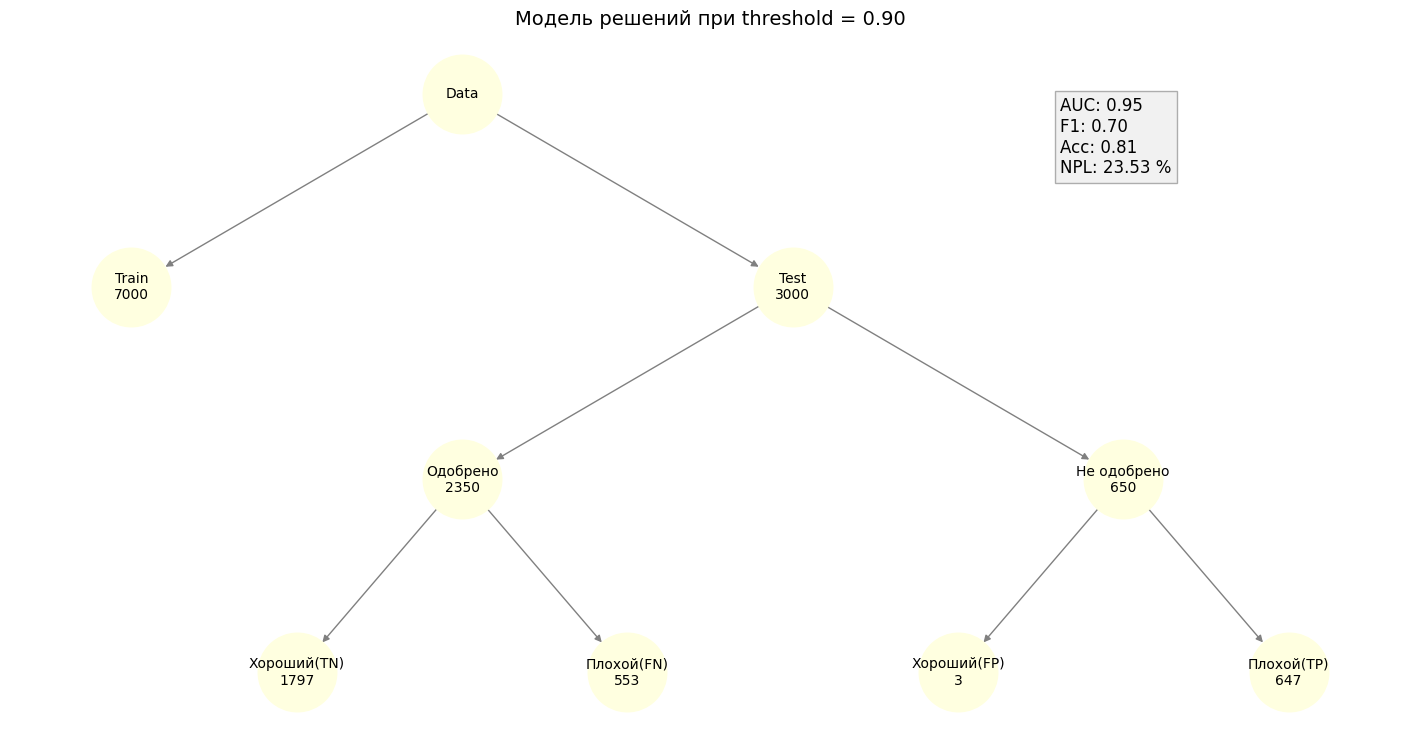

In [54]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Assuming X, y_test, y_train, y_proba are already defined
# (y_test: 0=good, 1=bad)
# (y_pred: 0=approved, 1=not approved)

total_data = len(X)
auc_score = roc_auc_score(y_test, y_probs)

thresholds = np.arange(0.1, 0.91, 0.1)

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    train_total = len(y_train)
    total = len(y_pred)

    # Правильные вычисления и названия переменных
    # True Negative (TN): Predicted=0 (Approved), Actual=0 (Good)
    TN = np.sum((y_pred == 0) & (y_test == 0))
    # False Negative (FN): Predicted=0 (Approved), Actual=1 (Bad)
    FN = np.sum((y_pred == 0) & (y_test == 1))
    # True Positive (TP): Predicted=1 (Not Approved), Actual=1 (Bad)
    TP = np.sum((y_pred == 1) & (y_test == 1))
    # False Positive (FP): Predicted=1 (Not Approved), Actual=0 (Good)
    FP = np.sum((y_pred == 1) & (y_test == 0))

    # Общее количество одобренных и неодобренных
    approved = TN + FN
    not_approved = TP + FP

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # NPL: процент плохих (bad) среди одобренных (approved)
    npl = round((FN / approved) * 100, 2) if approved > 0 else 0

    G = nx.DiGraph()

    G.add_node("Data", pos=(0, 5))
    G.add_node(f"Train\n{train_total}", pos=(-2, 4))
    G.add_node(f"Test\n{total}", pos=(2, 4))

    G.add_node(f"Одобрено\n{approved}", pos=(0, 3))
    G.add_node(f"Не одобрено\n{not_approved}", pos=(4, 3))

    # Правильные подписи для узлов
    G.add_node(f"Хороший(TN)\n{TN}", pos=(-1, 2))
    G.add_node(f"Плохой(FN)\n{FN}", pos=(1, 2))
    G.add_node(f"Хороший(FP)\n{FP}", pos=(3, 2))
    G.add_node(f"Плохой(TP)\n{TP}", pos=(5, 2))

    edges = [
        ("Data", f"Train\n{train_total}"),
        ("Data", f"Test\n{total}"),
        (f"Test\n{total}", f"Одобрено\n{approved}"),
        (f"Test\n{total}", f"Не одобрено\n{not_approved}"),
        (f"Одобрено\n{approved}", f"Хороший(TN)\n{TN}"),
        (f"Одобрено\n{approved}", f"Плохой(FN)\n{FN}"),
        (f"Не одобрено\n{not_approved}", f"Хороший(FP)\n{FP}"),
        (f"Не одобрено\n{not_approved}", f"Плохой(TP)\n{TP}"),
    ]
    G.add_edges_from(edges)

    pos = nx.get_node_attributes(G, 'pos')

    plt.figure(figsize=(14, 7))
    nx.draw(
        G, pos, with_labels=True,
        node_size=3200, node_color='lightyellow',
        font_size=10, edge_color='gray'
    )

    metrics_text = f"AUC: {auc_score:.2f}\nF1: {f1:.2f}\nAcc: {acc:.2f}\nNPL: {npl} %"
    plt.gcf().text(0.75, 0.8, metrics_text, fontsize=12, bbox=dict(facecolor='lightgrey', alpha=0.3))

    plt.title(f"Модель решений при threshold = {threshold:.2f}", fontsize=14)
    plt.axis('off')
    plt.tight_layout()

    # plt.show()
    # filename = f"model_tree_threshold_{threshold:.2f}.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # plt.close()

In [55]:
NPL = df['is_bad_client'].mean() * 100
print(f"NPL: {NPL:.2f}%")

NPL: 40.00%


In [56]:
thresholds = np.arange(0.1, 1.0, 0.01)

In [57]:
df['сумма_выдачи(markup)'] = ((df['сумма_выдачи(usd)'] + df['сумма_выдачи(usd)'] * 0.7)).astype(int)

In [61]:
lost_profit_markup_fp = []
lost_risk_ostatok_fn = []
predicted_npl_rate = []

total_clients = len(y)

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    # Упущенная выгода (Lost Profit): модель сказала "плохой", а клиент был "хороший"
    # Это False Positive (FP)
    fp_mask = (y_pred == 1) & (y_test == 0)
    fp_indices = X_test.loc[fp_mask].index

    # Считаем упущенную выгоду (markup) для этих клиентов
    fp_markup_sum = df.loc[fp_indices, 'сумма_выдачи(markup)'].astype(int).sum()
    lost_profit_markup_fp.append(fp_markup_sum)

    # Ошибка риска (Lost Risk): модель сказала "хороший", а клиент был "плохой"
    # Это False Negative (FN)
    fn_mask = (y_pred == 0) & (y_test == 1)
    fn_indices = X_test.loc[fn_mask].index

    # Считаем сумму остатка долга (risk) для этих клиентов
    fn_ostatok_sum = df.loc[fn_indices, 'остаток_суммы(usd)'].astype(int).sum()
    lost_risk_ostatok_fn.append(fn_ostatok_sum)

    predicted_bad_clients = sum(y_pred == 1)
    npl_rate = (predicted_bad_clients / total_clients) * 100 if total_clients > 0 else 0
    predicted_npl_rate.append(npl_rate)

total_loss = []
for fp, fn in zip(lost_profit_markup_fp, lost_risk_ostatok_fn):
    total_loss.append(fp + fn)

summary_df = pd.DataFrame({
    "Порог": thresholds,
    "FP (Упущенная выгода: markup)": lost_profit_markup_fp,
    "FN (остаток суммы USD)": lost_risk_ostatok_fn,
    "Общая потеря": total_loss,
    "Предсказанный NPL (%)": np.round(predicted_npl_rate, 2),
})

summary_df.to_csv("3month_losses.csv", index=False)

print(summary_df)

    Порог  FP (Упущенная выгода: markup)  FN (остаток суммы USD)  \
0    0.10                        1097589                   16073   
1    0.11                        1060258                   16859   
2    0.12                        1013066                   18174   
3    0.13                         961333                   19945   
4    0.14                         920347                   21173   
..    ...                            ...                     ...   
85   0.95                           2051                  297867   
86   0.96                           2051                  316480   
87   0.97                           2051                  340558   
88   0.98                           2051                  360156   
89   0.99                           2051                  391104   

    Общая потеря  Предсказанный NPL (%)  
0        1113662                  20.62  
1        1077117                  20.20  
2        1031240                  19.73  
3         98127

In [60]:
test_indices = X_test.index
df_test = df.loc[test_indices]

# Эта строка вычисляет общую сумму займа от всех фактически плохих клиентов
bad_client_loans_test = df_test[df_test['is_bad_client'] == 1]['остаток_суммы(usd)'].astype(int).sum()

# Исправленная строка вывода, которая правильно описывает значение
print("Фактическая общая сумма риска в тестовой выборке (USD):", bad_client_loans_test)

Фактическая общая сумма риска в тестовой выборке (USD): 444072


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('df2307.csv')
df.head()

,дата выдачи,семейное положение,сумма выдачи,остаток суммы,срок кредита (месяц),цикл,цель кредита,процентная ставка,возраст,пол,...,образование,должность,is_bad_client,year,usd_rate,shaped_bread(som),cottonseed oil(som),beef(som),сумма_выдачи(usd),остаток_суммы(usd)
0,2023-08-11,married,5000000.0,3746309.40,12.0,1.0,миграция,72.0,47.0,м,...,среднее,уста,1,2023,11269,2650,19750,77000,443,332
1,2023-09-05,married,5000000.0,4580890.30,12.0,1.0,миграция,72.0,28.0,м,...,среднее,уста,1,2023,11269,2650,19750,77000,443,406
2,2023-08-18,single,4000000.0,478947.03,12.0,1.0,миграция,72.0,30.0,ж,...,среднее,богбон,1,2023,11269,2650,19750,77000,354,42
3,2023-09-04,single,5000000.0,319060.65,12.0,1.0,миграция,72.0,40.0,м,...,среднее,шифокор,1,2023,11269,2650,19750,77000,443,28
4,2023-09-13,married,4000000.0,2673022.36,12.0,1.0,миграция,72.0,22.0,м,...,среднее,уста,1,2023,11269,2650,19750,77000,354,237


In [4]:

# Эта строка вычисляет общую сумму займа от всех фактически плохих клиентов
bad_client_loans_test = df[df['is_bad_client'] == 1]['остаток_суммы(usd)'].astype(int).sum()

# Исправленная строка вывода, которая правильно описывает значение
print("Фактическая общая сумма риска в тестовой выборке (USD):", bad_client_loans_test)

Фактическая общая сумма риска в тестовой выборке (USD): 240752
